In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝 
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df = pd.read_csv('data/merged_final_data.csv')

In [3]:
cols = df.columns
cols 

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'category', 'seller_city',
       'seller_state', 'order_purchase_dayofweek', 'order_purchase_month',
       'approved_days', 'dispatch_days', 'delivery_days',
       'expected_delivery_days', 'delay_days', 'delay_days_int', 'is_delayed',
       'delay_days_cat', 'main_category', 'sub_category', 'distance_km',
       'cross_state'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  str    
 1   customer_id               109294 non-null  str    
 2   customer_unique_id        109294 non-null  str    
 3   customer_city             109294 non-null  str    
 4   customer_state            109294 non-null  str    
 5   order_item_id             109294 non-null  int64  
 6   seller_id                 109294 non-null  str    
 7   shipping_limit_date       109294 non-null  str    
 8   price                     109294 non-null  float64
 9   freight_value             109294 non-null  float64
 10  review_score              109294 non-null  int64  
 11  category                  107749 non-null  str    
 12  seller_city               109294 non-null  str    
 13  seller_state              109294 non-null  str    
 14 

In [5]:
df.isna().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_item_id                  0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
review_score                   0
category                    1545
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_category                  0
sub_category                   0
distance_km                    0
cross_state                    0
dtype: int64

### 위도 경도 활용해서 거리 파생변수 생성

In [6]:
# Haversine 거리 계산 함수 (지구 곡률을 반영한 두 좌표 간의 직선 거리 km)
def haversine_vectorize(lat1, lon1, lat2, lon2):
    # 라디안 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c # 6371: 지구의 평균 반지름(km)
    return km

# 거리(distance_km) 파생 변수 생성
df['distance_km'] = haversine_vectorize(
    df['customer_lat'], df['customer_lng'],
    df['seller_lat'], df['seller_lng']
)

KeyError: 'customer_lat'

#### 거리 파생변수 결측치 처리

In [ ]:
print(f"distance_km 결측치 처리 전 행 수 : {len(df)}")
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median()) # 거리 중앙값으로 대체
print(f"distance_km 결측치 처리 후 행 수 : {len(df)}")

# 모델 학습에 불필요한 중간 컬럼 삭제
cols_to_drop = ['customer_zip_code_prefix', 'seller_zip_code_prefix', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
df = df.drop(columns=cols_to_drop)

distance_km 결측치 처리 전 행 수 : 95784
distance_km 결측치 처리 후 행 수 : 95784


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     95784 non-null  int64  
 1   order_id                  95784 non-null  str    
 2   customer_id               95784 non-null  str    
 3   customer_unique_id        95784 non-null  str    
 4   customer_city             95784 non-null  str    
 5   customer_state            95784 non-null  str    
 6   total_items_count         95784 non-null  int64  
 7   seller_id                 95784 non-null  str    
 8   price                     95784 non-null  float64
 9   freight_value             95784 non-null  float64
 10  review_score              95784 non-null  int64  
 11  category                  94414 non-null  str    
 12  seller_city               95784 non-null  str    
 13  seller_state              95784 non-null  str    
 14  order_purchase_da

In [ ]:
df.isna().sum()

index                          0
order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
total_items_count              0
seller_id                      0
price                          0
freight_value                  0
review_score                   0
category                    1370
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_category                  0
sub_category                   0
distance_km                    0
dtype: int64

delay_days—> int형
delay_days_int, delay_days_cat 제거

In [ ]:
df['delay_days_cat'].value_counts()

delay_days_cat
조기           88010
1-3일 지연       2591
10일 이상 지연     2435
4-6일 지연       1374
7-9일 지연       1199
정시             175
Name: count, dtype: int64

### 머신러닝 모델 생성시 절대 안쓸만한 컬럼 제거

In [ ]:
cols_to_drop = ['order_id','customer_id','customer_city','customer_state','seller_id',
                'category','seller_city','seller_state','delay_days_int']
df = df.drop(columns=cols_to_drop)
df['delay_days'] = df['delay_days'].astype(int) # delay_days 정수화

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     95784 non-null  int64  
 1   customer_unique_id        95784 non-null  str    
 2   total_items_count         95784 non-null  int64  
 3   price                     95784 non-null  float64
 4   freight_value             95784 non-null  float64
 5   review_score              95784 non-null  int64  
 6   order_purchase_dayofweek  95784 non-null  str    
 7   order_purchase_month      95784 non-null  int64  
 8   approved_days             95784 non-null  int64  
 9   dispatch_days             95784 non-null  int64  
 10  delivery_days             95784 non-null  int64  
 11  expected_delivery_days    95784 non-null  int64  
 12  delay_days                95784 non-null  int64  
 13  is_delayed                95784 non-null  int64  
 14  delay_days_cat   

In [ ]:
df.isna().sum()

index                       0
customer_unique_id          0
total_items_count           0
price                       0
freight_value               0
review_score                0
order_purchase_dayofweek    0
order_purchase_month        0
approved_days               0
dispatch_days               0
delivery_days               0
expected_delivery_days      0
delay_days                  0
is_delayed                  0
delay_days_cat              0
main_category               0
sub_category                0
distance_km                 0
dtype: int64

In [ ]:
df.head()

,index,customer_unique_id,total_items_count,price,freight_value,review_score,order_purchase_dayofweek,order_purchase_month,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,is_delayed,delay_days_cat,main_category,sub_category,distance_km
0,0,7c396fd4830fd04220f754e42b4e5bff,1,29.99,8.72,4,monday,10,0,2,8,15,-7,0,조기,Home & Living,Kitchen & Housewares,18.538322
1,1,af07308b275d755c9edb36a90c618231,1,118.70,22.76,4,tuesday,7,1,1,13,19,-5,0,조기,Health & Beauty & Fashion,Health & Beauty,849.520470
2,2,3a653a41f6f9fc3d2a113cf8398680e8,1,159.90,19.22,5,wednesday,8,0,0,9,26,-17,0,조기,Others,Automotive,514.407596
3,3,7c142cf63193a1473d2e66489a9ae977,1,45.00,27.20,5,saturday,11,0,3,13,26,-13,0,조기,Others,Pet Shop,1822.132331
4,4,72632f0f9dd73dfee390c9b22eb56dd6,1,19.90,8.72,5,tuesday,2,0,0,2,12,-9,0,조기,DIY & Industry,Industry & Office,29.765008


In [ ]:
# feature engineering? 까짓거 한번 해보죠

df_ml = df.copy()

# 베송속도 관련 파생피처들
df_ml['delivery_speed'] = df_ml['distance_km'] / df_ml['delivery_days']
df_ml['day_per_km'] = df_ml['delivery_days'] / df_ml['distance_km']
df_ml['delivery_ratio'] = df_ml['delivery_days'] / df_ml['expected_delivery_days']

# 가격 대비 배송비 & 상품당 배송비
df_ml['freight_ratio'] = df_ml['freight_value'] / df_ml['price']
df_ml['freight_per_item'] = df_ml['freight_value'] / df_ml['total_items_count']


# 거리 구간화
def distance_group(km):
    if km < 100:
        return 0
    elif km < 400:
        return 1
    elif km < 700:
        return 2
    elif km < 1000:
        return 3
    else:
        return 4

df_ml['distance_cat'] = df_ml['distance_km'].apply(distance_group).astype('int')



# delivery_days * distance_km
df_ml["delivery_distance"] = (df_ml["delivery_days"].fillna(0) * df_ml["distance_km"].fillna(0))

# delivery_days * price
df_ml["delivery_price"] = (df_ml["delivery_days"] * df_ml["price"])


df_ml = df_ml.replace([np.inf, -np.inf], np.nan)
num_cols = df_ml.select_dtypes(include=[np.number]).columns
df_ml[num_cols] = df_ml[num_cols].fillna(0)


In [ ]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     95784 non-null  int64  
 1   customer_unique_id        95784 non-null  str    
 2   total_items_count         95784 non-null  int64  
 3   price                     95784 non-null  float64
 4   freight_value             95784 non-null  float64
 5   review_score              95784 non-null  int64  
 6   order_purchase_dayofweek  95784 non-null  str    
 7   order_purchase_month      95784 non-null  int64  
 8   approved_days             95784 non-null  int64  
 9   dispatch_days             95784 non-null  int64  
 10  delivery_days             95784 non-null  int64  
 11  expected_delivery_days    95784 non-null  int64  
 12  delay_days                95784 non-null  int64  
 13  is_delayed                95784 non-null  int64  
 14  delay_days_cat   

In [ ]:
# 분류모델 시 그룹화 함수 정의
def group_score(score):
    if score >= 4: return 1   # High (긍정)
    else: return 0            # Low (부정)

X = df_ml.drop(columns=['review_score','index','customer_unique_id'])
y = df_ml['review_score'].apply(group_score)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

# Train+Valid / Test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train / Valid 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.2,
    random_state=42,
    stratify=y_train_valid
)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, balanced_accuracy_score


model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)


# 예측
valid_proba = model.predict_proba(X_valid)[:,1]
test_proba = model.predict_proba(X_test)[:,1]




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 48380, number of negative: 12921
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3033
[LightGBM] [Info] Number of data points in the train set: 61301, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [ ]:
# threshold 평가 함수
def evaluate_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    neg_recall = recall_score(y_true, pred, pos_label=0)
    macro_f1 = f1_score(y_true, pred, average="macro")
    weighted_f1 = f1_score(y_true, pred, average="weighted")
    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)


    return {
        "threshold": threshold,
        "neg_recall": neg_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": acc,
        "balanced_acc": bal_acc,
        "tn": cm[0,0],
        "fp": cm[0,1],
        "fn": cm[1,0],
        "tp": cm[1,1],
    }


# 0.01씩 threshold 바꿔가며 비교
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for th in thresholds:
    row = evaluate_threshold(y_valid, valid_proba, th)
    results.append(row)

threshold_df = pd.DataFrame(results)




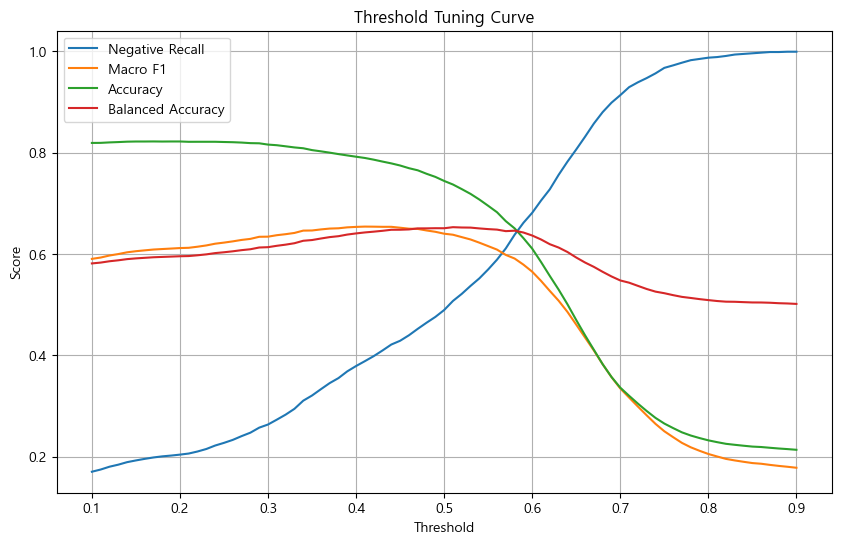

In [ ]:
# 시각화

plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["neg_recall"], label="Negative Recall")
plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["balanced_acc"], label="Balanced Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# neg_recall과 balanced_acc 차이
threshold_df["gap"] = (threshold_df["neg_recall"] - threshold_df["balanced_acc"]).abs()

# 두 값이 가장 가까운 threshold
best_row = threshold_df.loc[threshold_df["gap"].idxmin()]
best_threshold = best_row["threshold"]

print("선택된 threshold:", best_threshold)
print(best_row[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])

선택된 threshold: 0.5799999999999997
threshold       0.580000
neg_recall      0.638080
balanced_acc    0.646091
macro_f1        0.591133
accuracy        0.650724
Name: 48, dtype: float64


In [ ]:
# 평가

valid_pred = (valid_proba >= best_threshold).astype(int)
test_pred = (test_proba >= best_threshold).astype(int)


print("VALID ACC:", accuracy_score(y_valid, valid_pred))
print("VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred))
print("VALID Negative Recall:", recall_score(y_valid, valid_pred, pos_label=0))
print("VALID F1(macro):", f1_score(y_valid, valid_pred, average='macro'))
print("VALID F1(weighted):", f1_score(y_valid, valid_pred, average='weighted'))
print(classification_report(y_valid, valid_pred, zero_division=0))
print("VALID confusion matrix")
print(confusion_matrix(y_valid, valid_pred))

print("TEST ACC:", accuracy_score(y_test, test_pred))
print("TEST Balanced ACC:", balanced_accuracy_score(y_test, test_pred))
print("TEST Negative Recall:", recall_score(y_test, test_pred, pos_label=0))
print("TEST F1(macro):", f1_score(y_test, test_pred, average='macro'))
print("TEST F1(weighted):", f1_score(y_test, test_pred, average='weighted'))
print(classification_report(y_test, test_pred, zero_division=0))
print("TEST confusion matrix")
print(confusion_matrix(y_test, test_pred))


VALID ACC: 0.6507242594284223
VALID Balanced ACC: 0.6460905122282832
VALID Negative Recall: 0.6380804953560372
VALID F1(macro): 0.5911326708183805
VALID F1(weighted): 0.6814315982866133
              precision    recall  f1-score   support

           0       0.33      0.64      0.44      3230
           1       0.87      0.65      0.75     12096

    accuracy                           0.65     15326
   macro avg       0.60      0.65      0.59     15326
weighted avg       0.76      0.65      0.68     15326

VALID confusion matrix
[[2061 1169]
 [4184 7912]]
TEST ACC: 0.6525030015138069
TEST Balanced ACC: 0.6440805043403233
TEST Negative Recall: 0.6295195641406637
TEST F1(macro): 0.5912475388557098
TEST F1(weighted): 0.682775556886235
              precision    recall  f1-score   support

           0       0.33      0.63      0.43      4038
           1       0.87      0.66      0.75     15119

    accuracy                           0.65     19157
   macro avg       0.60      0.64      

In [ ]:
# 피처 중요도 확인

imp = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(imp.head(30))

freight_ratio                         1165
price                                 1111
delivery_price                        1060
delivery_ratio                        1032
distance_km                            989
freight_value                          934
delivery_distance                      914
delay_days                             910
expected_delivery_days                 903
freight_per_item                       896
delivery_speed                         829
order_purchase_month                   646
dispatch_days                          601
delivery_days                          589
day_per_km                             571
approved_days                          179
total_items_count                      135
order_purchase_dayofweek_wednesday     102
order_purchase_dayofweek_sunday         90
order_purchase_dayofweek_tuesday        88
order_purchase_dayofweek_monday         82
order_purchase_dayofweek_thursday       76
sub_category_Health & Beauty            70
sub_categor

- 배송비 비율이 리뷰 점수에 가장 큰 영향을 준다
- 예상 배송보다 늦어질수록 부정 리뷰 확률이 증가한다
- 배송 거리와 배송 시간의 상호작용이 만족도에 큰 영향을 준다
- 상품 가격이 높을수록 배송 지연에 더 민감하다